# 02 - Ticket Classification Model

## AI Support Copilot with RAG and Ticket Classification

This notebook trains a machine learning model to classify customer support tickets into ticket types using the combined ticket subject and ticket description.

The trained model will later be used by the FastAPI backend and Streamlit dashboard.

Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

Setting Paths

In [2]:
DATA_PATH = Path("../data/processed/cleaned_support_tickets.csv")
MODEL_DIR = Path("../models")
MODEL_PATH = MODEL_DIR / "ticket_type_classifier.joblib"

DATA_PATH.exists()

True

Load cleaned dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 8469
Columns: 25


,ticket_id,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_text,ticket_status,...,customer_satisfaction_rating,description_length,subject_length,resolution_length,resolution_was_missing,customer_satisfaction_rating_was_missing,first_response_time_was_missing,time_to_resolution_was_missing,ticket_description_was_missing,ticket_subject_was_missing
0,1,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Product setup I'm having an issue with the {pr...,Pending Customer Response,...,-1.0,284,13,0,1,1,0,1,0,0
1,2,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility I'm having an issue w...,Pending Customer Response,...,-1.0,282,24,0,1,1,0,1,0,0
2,3,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Network problem I'm facing a problem with my {...,Closed,...,3.0,275,15,44,0,0,0,0,0,0
3,4,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Account access I'm having an issue with the {p...,Closed,...,3.0,262,14,45,0,0,0,0,0,0
4,5,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Data loss I'm having an issue with the {produc...,Closed,...,1.0,333,9,27,0,0,0,0,0,0


Check target distribution

In [4]:
df["ticket_type"].value_counts()

ticket_type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

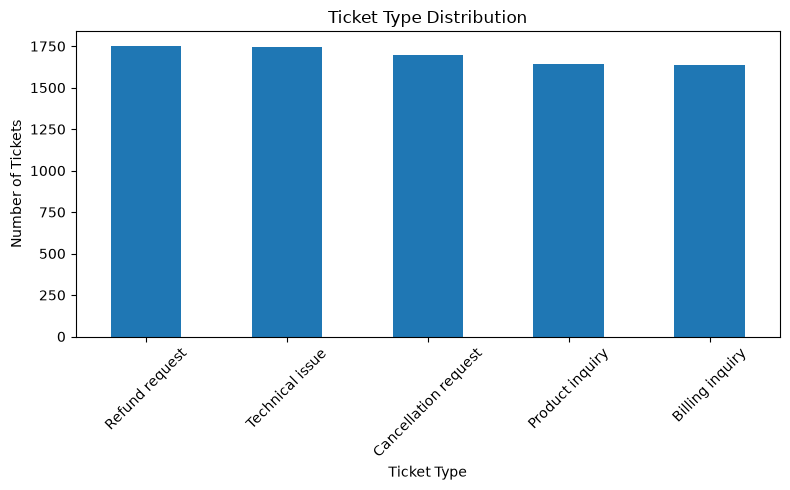

In [5]:
df["ticket_type"].value_counts().plot(kind="bar", figsize=(8, 5))
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This confirms whether the classes are balanced.

Prepare features and target

In [6]:
X = df["ticket_text"]
y = df["ticket_type"]

print("Feature sample:")
print(X.head())

print("\nTarget sample:")
print(y.head())

Feature sample:
0    Product setup I'm having an issue with the {pr...
1    Peripheral compatibility I'm having an issue w...
2    Network problem I'm facing a problem with my {...
3    Account access I'm having an issue with the {p...
4    Data loss I'm having an issue with the {produc...
Name: ticket_text, dtype: str

Target sample:
0    Technical issue
1    Technical issue
2    Technical issue
3    Billing inquiry
4    Billing inquiry
Name: ticket_type, dtype: str


Train/test split

Use stratification so each ticket type is represented fairly in train and test sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 6775
Testing records: 1694


Build baseline model

We start with a simple but strong text classification pipeline:
The reason for using this model is TF-IDF converts ticket text into numerical features.
Logistic Regression is fast, interpretable, and a strong baseline for text classification.

In [8]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

Train baseline model

In [9]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](5,)","['Billing inquiry','Cancellation request','Product inquiry', 'Refund request','Technical issue']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are give

Evaluate baseline model

In [10]:
y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.2125

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.24      0.23       327
Cancellation request       0.22      0.22      0.22       339
     Product inquiry       0.22      0.25      0.23       328
      Refund request       0.20      0.17      0.18       351
     Technical issue       0.22      0.18      0.20       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



Confusion matrix

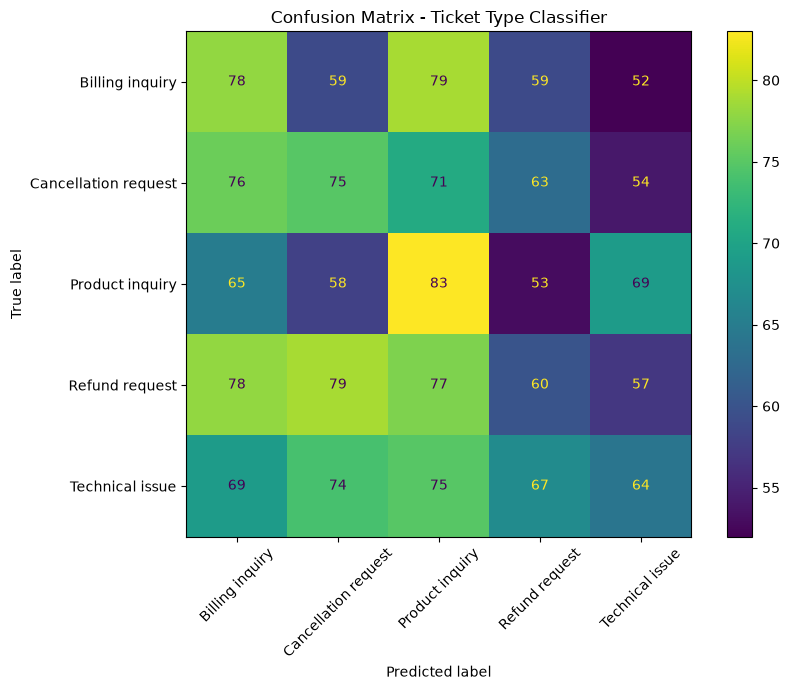

In [11]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Ticket Type Classifier")
plt.tight_layout()
plt.show()

Cross Validation

In [12]:
cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("Std CV Accuracy:", round(cv_scores.std(), 4))

CV Scores: [0.19303424 0.21015348 0.19893743 0.18831169 0.20850561]
Mean CV Accuracy: 0.1998
Std CV Accuracy: 0.0085


Compare with Another Model
Random Forest model

In [13]:
rf_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2)
    )),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

Train and evaluate Random Forest

In [14]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.1978

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.23      0.21       327
Cancellation request       0.17      0.16      0.17       339
     Product inquiry       0.20      0.20      0.20       328
      Refund request       0.20      0.20      0.20       351
     Technical issue       0.23      0.20      0.21       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



Model comparison

In [15]:
model_results = pd.DataFrame({
    "model": ["TF-IDF + Logistic Regression", "TF-IDF + Random Forest"],
    "accuracy": [accuracy, rf_accuracy]
})

model_results

,model,accuracy
0,TF-IDF + Logistic Regression,0.212515
1,TF-IDF + Random Forest,0.197757


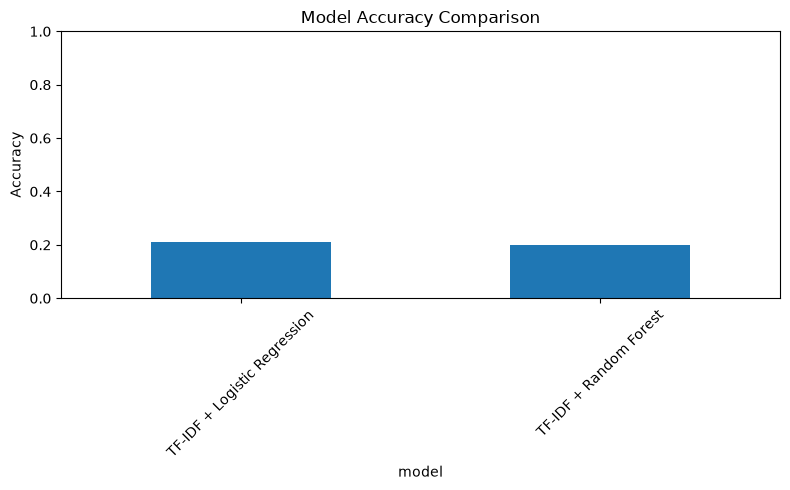

In [16]:
model_results.set_index("model")["accuracy"].plot(kind="bar", figsize=(8, 5))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Test Model on Sample Tickets
Sample predictions

In [17]:
sample_tickets = [
    "I was charged twice for my subscription and need help with billing.",
    "The product stopped working after the latest update and keeps showing an error.",
    "I want to cancel my order and get confirmation.",
    "Can you tell me more about the features of this product?",
    "I requested a refund but have not received the money yet."
]

sample_predictions = baseline_model.predict(sample_tickets)

for ticket, prediction in zip(sample_tickets, sample_predictions):
    print("Ticket:", ticket)
    print("Predicted Type:", prediction)
    print("-" * 80)

Ticket: I was charged twice for my subscription and need help with billing.
Predicted Type: Refund request
--------------------------------------------------------------------------------
Ticket: The product stopped working after the latest update and keeps showing an error.
Predicted Type: Product inquiry
--------------------------------------------------------------------------------
Ticket: I want to cancel my order and get confirmation.
Predicted Type: Billing inquiry
--------------------------------------------------------------------------------
Ticket: Can you tell me more about the features of this product?
Predicted Type: Product inquiry
--------------------------------------------------------------------------------
Ticket: I requested a refund but have not received the money yet.
Predicted Type: Billing inquiry
--------------------------------------------------------------------------------


Prediction probabilities

This helps later in the API and dashboard.

In [18]:
sample_probabilities = baseline_model.predict_proba(sample_tickets)
classes = baseline_model.classes_

for ticket, probs in zip(sample_tickets, sample_probabilities):
    print("Ticket:", ticket)
    prob_df = pd.DataFrame({
        "ticket_type": classes,
        "probability": probs
    }).sort_values("probability", ascending=False)
    
    print(prob_df)
    print("-" * 80)

Ticket: I was charged twice for my subscription and need help with billing.
            ticket_type  probability
3        Refund request     0.370738
2       Product inquiry     0.242303
4       Technical issue     0.164973
1  Cancellation request     0.134320
0       Billing inquiry     0.087666
--------------------------------------------------------------------------------
Ticket: The product stopped working after the latest update and keeps showing an error.
            ticket_type  probability
2       Product inquiry     0.301000
0       Billing inquiry     0.254497
4       Technical issue     0.168497
3        Refund request     0.151220
1  Cancellation request     0.124786
--------------------------------------------------------------------------------
Ticket: I want to cancel my order and get confirmation.
            ticket_type  probability
0       Billing inquiry     0.239116
3        Refund request     0.216234
1  Cancellation request     0.215484
2       Product inquiry   

Save Model
Save best model

For now, save Logistic Regression unless Random Forest performs clearly better.

In [19]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = baseline_model
joblib.dump(best_model, MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: ..\models\ticket_type_classifier.joblib


Load model and test

In [20]:
loaded_model = joblib.load(MODEL_PATH)

test_ticket = "I cannot access my account and password reset is not working."

prediction = loaded_model.predict([test_ticket])[0]
probability = loaded_model.predict_proba([test_ticket]).max()

print("Test Ticket:", test_ticket)
print("Predicted Type:", prediction)
print("Confidence:", round(probability, 4))

Test Ticket: I cannot access my account and password reset is not working.
Predicted Type: Technical issue
Confidence: 0.3273


Save model metrics

Creating a simple metrics file for documentation.

In [21]:
metrics = {
    "model_name": "TF-IDF + Logistic Regression",
    "test_accuracy": round(float(accuracy), 4),
    "cv_mean_accuracy": round(float(cv_scores.mean()), 4),
    "cv_std_accuracy": round(float(cv_scores.std()), 4),
    "training_records": int(X_train.shape[0]),
    "testing_records": int(X_test.shape[0]),
    "target_classes": list(classes)
}

metrics

{'model_name': 'TF-IDF + Logistic Regression',
 'test_accuracy': 0.2125,
 'cv_mean_accuracy': 0.1998,
 'cv_std_accuracy': 0.0085,
 'training_records': 6775,
 'testing_records': 1694,
 'target_classes': ['Billing inquiry',
  'Cancellation request',
  'Product inquiry',
  'Refund request',
  'Technical issue']}

Saving it:

In [22]:
import json

metrics_path = MODEL_DIR / "ticket_type_classifier_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"Metrics saved to: {metrics_path}")

Metrics saved to: ..\models\ticket_type_classifier_metrics.json


## Dataset Signal Diagnosis

The initial classification results are close to random baseline performance. Since the dataset has five ticket types, random guessing would achieve around 20% accuracy. The Logistic Regression model achieved approximately 21%, which suggests that the ticket text may not contain enough meaningful signal to predict ticket type.

The following checks investigate whether the issue is caused by synthetic/generic text, weak relationship between text and labels, or data quality limitations.

In [23]:
for ticket_type in df["ticket_type"].unique():
    print("\n" + "=" * 100)
    print("Ticket Type:", ticket_type)
    print("=" * 100)
    
    samples = df[df["ticket_type"] == ticket_type]["ticket_text"].sample(5, random_state=42)
    
    for text in samples:
        print(text)
        print("-" * 100)


Ticket Type: Technical issue
Product setup I'm having an issue with the {product_purchased}. Please assist. I've added a new product, {id} {product_purchased}, which requires 1 sign-on time and adds an option on the right side to I'm unable to find the option to perform the desired action in the {product_purchased}. Could you please guide me through the steps?
----------------------------------------------------------------------------------------------------
Software bug I'm having an issue with the {product_purchased}. Please assist. I'm not sure if this issue is specific to my device or if others have reported similar problems.
----------------------------------------------------------------------------------------------------
Hardware issue I'm having an issue with the {product_purchased}. Please assist.

The first thing you need to do when upgrading a product is to update your repository.

git is a git remote that comes with everything you need to This problem started occurring a

## Label Quality Review

A manual review of sampled records by ticket type showed that several records appear to be incorrectly labeled.

For example:
- Some tickets labeled as `Billing inquiry` describe technical issues.
- Some tickets labeled as `Cancellation request` describe technical issues.
- Some tickets labeled as `Refund request` also appear to describe technical problems.

This explains why the supervised text classification model performed close to random baseline. Since the dataset has five ticket types, a random baseline would be approximately 20%. The Logistic Regression model achieved around 21%, which suggests that the text features do not reliably match the provided labels.

Conclusion:
The dataset is useful for SQL analytics, dashboarding, workflow simulation, and RAG-based support assistance. However, the `ticket_type` column is not reliable enough to train a high-quality supervised classifier without relabeling or using a better-labeled dataset.

## Summary

A baseline text classification model was trained to predict `ticket_type` using the combined ticket subject and description.

Key steps completed:
- Loaded the cleaned support ticket dataset.
- Used `ticket_text` as the input feature.
- Used `ticket_type` as the target label.
- Trained TF-IDF based models including Logistic Regression and Random Forest.
- Evaluated the models using accuracy, classification report, confusion matrix, and cross-validation.
- Compared model performance against the expected random baseline for a five-class problem.

Key finding:
The best model achieved approximately 21% accuracy, which is close to the random baseline of 20% for five ticket classes. Manual inspection of sampled records showed that several ticket labels appear inconsistent with the actual ticket text. For example, some tickets labeled as billing, cancellation, or refund requests appear to describe technical issues.

Conclusion:
The supervised ticket classification task is limited by noisy or inconsistent labels in the dataset. Therefore, the classifier will be retained as a baseline experiment, but the main project will focus on RAG-based support assistance, SQL analytics, dashboarding, and AI workflow automation.

Next step:
Create a reusable baseline prediction script, then move to SQL database loading and RAG-based support response generation.

Saving Baseline Model for Future Work. 

In [24]:
MODEL_PATH = MODEL_DIR / "baseline_ticket_type_classifier.joblib"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

baseline_classifier = baseline_model
joblib.dump(baseline_classifier, MODEL_PATH)

print(f"Baseline model saved to: {MODEL_PATH}")

Baseline model saved to: ..\models\baseline_ticket_type_classifier.joblib


Saving Metrics

In [ ]:
import json

metrics = {
    "model_name": "TF-IDF + Logistic Regression",
    "model_status": "baseline_only",
    "test_accuracy": round(float(accuracy), 4),
    "cv_mean_accuracy": round(float(cv_scores.mean()), 4),
    "cv_std_accuracy": round(float(cv_scores.std()), 4),
    "random_baseline_estimate": 0.20,
    "training_records": int(X_train.shape[0]),
    "testing_records": int(X_test.shape[0]),
    "target_classes": list(baseline_model.classes_),
    "main_finding": "Model performance is close to random baseline due to noisy or inconsistent ticket_type labels.",
    "recommended_use": "Use only as a baseline experiment, not as a production-quality classifier."
}

metrics_path = MODEL_DIR / "baseline_ticket_type_classifier_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"Metrics saved to: {metrics_path}")

Metrics saved to: ..\models\baseline_ticket_type_classifier_metrics.json


: 